In [1]:
import pandas as pd
import numpy as np
import torch
import os
from torch.utils.data import Dataset
from sklearn.metrics import f1_score, accuracy_score
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    TrainingArguments, 
    Trainer, 
    EarlyStoppingCallback,
    DataCollatorWithPadding
)

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_NAME = "ai4bharat/IndicBERTv2-MLM-only"
DATA_DIR = "/kaggle/input/datasets/priyonteemojumder/prompt-recovery1" 

# Style Mapping
LABEL2ID = {
    "Formal": 0, "Informal": 1, "Optimistic": 2, "Pessimistic": 3,
    "Humorous": 4, "Serious": 5, "Inspiring": 6, "Authoritative": 7, "Persuasive": 8
}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

In [3]:
def load_clean_data(file_name, is_test=False):
    path = os.path.join(DATA_DIR, file_name)
    df = pd.read_csv(path)
    
    # Standardize column names (strips spaces and converts to upper for matching)
    df.columns = df.columns.str.strip()
    
    INPUT_COL = "CHANGE STYLE"
    LABEL_COL = "STYLE"
    ID_COL = "ID"
    
    # Cleaning
    df = df.dropna(subset=[INPUT_COL])
    df[INPUT_COL] = df[INPUT_COL].astype(str).str.strip()
    
    if not is_test:
        df = df.dropna(subset=[LABEL_COL])
        df['label'] = df[LABEL_COL].str.strip().map(LABEL2ID)
        df = df.dropna(subset=['label'])
        df['label'] = df['label'].astype(int)
        return df[['ID', 'CHANGE STYLE', 'ORIGINAL TRANSCRIPTS', 'label']]
    else:
        return df[['ID', 'CHANGE STYLE', 'ORIGINAL TRANSCRIPTS']]

print("Loading Train, Dev, and Test sets...")
train_df = load_clean_data("train.csv")
dev_df = load_clean_data("dev.csv")
test_df = load_clean_data("test.csv", is_test=True)

Loading Train, Dev, and Test sets...


In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class TeluguStyleDataset(Dataset):
    def __init__(self, df, is_test=False):
        self.encodings = tokenizer(
            df["CHANGE STYLE"].tolist(), 
            truncation=True, 
            padding=True, 
            max_length=512
        )
        self.is_test = is_test
        if not is_test:
            self.labels = df["label"].tolist()

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        if not self.is_test:
            item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.encodings.input_ids)

train_dataset = TeluguStyleDataset(train_df)
dev_dataset = TeluguStyleDataset(dev_df)
test_dataset = TeluguStyleDataset(test_df, is_test=True)

In [6]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    f1 = f1_score(labels, preds, average='macro')
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "macro_f1": f1}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, 
    num_labels=9,
    id2label=ID2LABEL,
    label2id=LABEL2ID
).to(DEVICE)

training_args = TrainingArguments(
    output_dir="./telugu_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    
    # --- DISK FIXES ---
    save_total_limit=1,              # ONLY keep the 1 best model. Deletes others.
    load_best_model_at_end=True,     # Required for high accuracy
    metric_for_best_model="macro_f1",
    
    # --- ACCURACY BOOSTERS ---
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    num_train_epochs=15,             # Increased epochs
    weight_decay=0.01,
    warmup_ratio=0.1,
    fp16=torch.cuda.is_available(),
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ai4bharat/IndicBERTv2-MLM-only
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if y

In [7]:
print("\n🚀 Starting Fine-Tuning on IndicBERT v2...")
trainer.train()


🚀 Starting Fine-Tuning on IndicBERT v2...


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,No log,4.393822,0.117450,0.063561
2,No log,4.034966,0.218121,0.174829
3,No log,3.876869,0.268456,0.207319
4,No log,3.616672,0.291946,0.239864
5,No log,3.580478,0.312081,0.265689
6,3.931706,3.467173,0.335570,0.310673
7,3.931706,3.514720,0.322148,0.305146
8,3.931706,3.436686,0.332215,0.314346
9,3.931706,3.369554,0.355705,0.339820
10,3.931706,3.339067,0.352349,0.329767


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=1410, training_loss=3.2228261528285684, metrics={'train_runtime': 2818.0236, 'train_samples_per_second': 15.894, 'train_steps_per_second': 0.5, 'total_flos': 1.178548484281344e+16, 'train_loss': 3.2228261528285684, 'epoch': 15.0})

In [8]:
print("\n🔍 Running predictions on Test Set...")
test_results = trainer.predict(test_dataset)
test_preds = np.argmax(test_results.predictions, axis=-1)


🔍 Running predictions on Test Set...


In [9]:
test_df['STYLE'] = [ID2LABEL[p] for p in test_preds]
output_file = "submission.csv"
test_df[['ID', 'STYLE']].to_csv(output_file, index=False)

print(f"\n✅ Success! File saved as: {output_file}")
print(test_df[['ID', 'STYLE']].head())


✅ Success! File saved as: submission.csv
              ID          STYLE
0  PR_TE_TE_0001  Authoritative
1  PR_TE_TE_0002  Authoritative
2  PR_TE_TE_0003      Inspiring
3  PR_TE_TE_0004       Informal
4  PR_TE_TE_0005     Optimistic


🚀 Running Gold Evaluation...


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


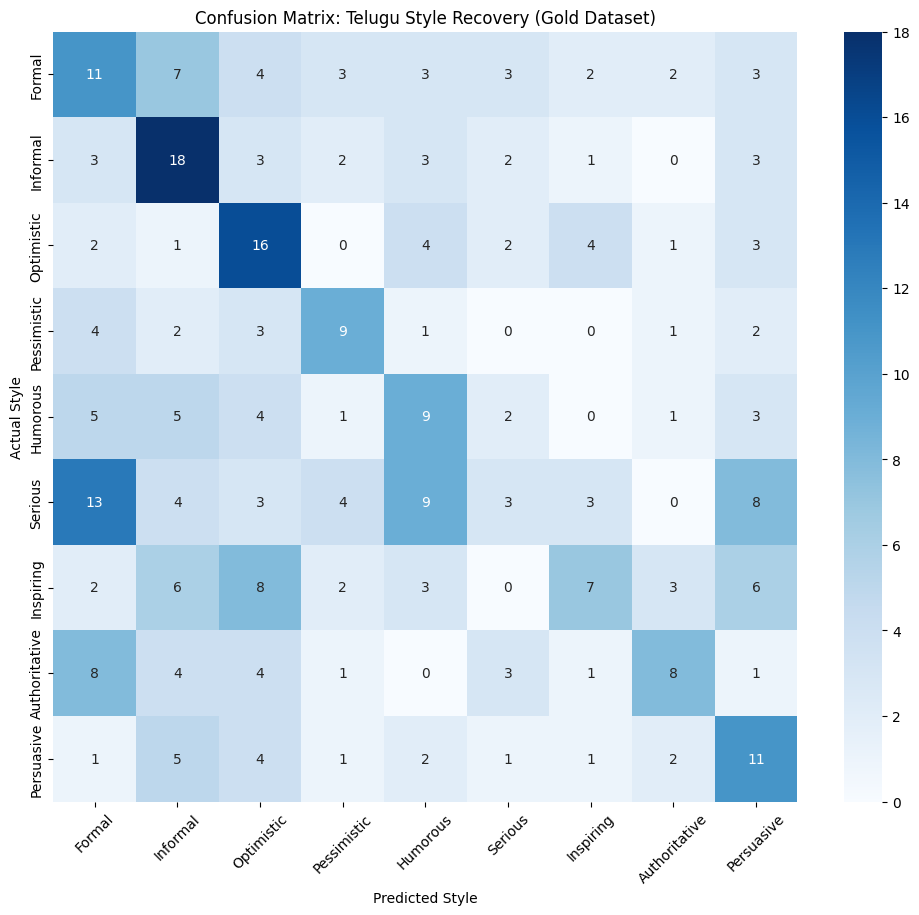


📝 Classification Report for ACL 2026 Paper:
               precision    recall  f1-score   support

       Formal       0.22      0.29      0.25        38
     Informal       0.35      0.51      0.41        35
   Optimistic       0.33      0.48      0.39        33
  Pessimistic       0.39      0.41      0.40        22
     Humorous       0.26      0.30      0.28        30
      Serious       0.19      0.06      0.10        47
    Inspiring       0.37      0.19      0.25        37
Authoritative       0.44      0.27      0.33        30
   Persuasive       0.28      0.39      0.32        28

     accuracy                           0.31       300
    macro avg       0.31      0.32      0.30       300
 weighted avg       0.30      0.31      0.29       300



In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
import numpy as np

gold_labels_df = pd.read_csv('/kaggle/input/datasets/gold-dataset/PR_test_labels.xlsx - Sheet1.csv')
gold_labels_df.columns = gold_labels_df.columns.str.strip()

test_df_clean = test_df.drop(columns=['STYLE']) if 'STYLE' in test_df.columns else test_df.copy()
gold_df = test_df_clean.merge(gold_labels_df, on='ID')

gold_df['input_text'] = gold_df['CHANGE STYLE'].astype(str) + " " + gold_df['ORIGINAL TRANSCRIPTS'].astype(str)

gold_labels_list = [LABEL2ID[str(label).strip()] for label in gold_df['STYLE']]

eval_gold_dataset = TeluguStyleDataset(gold_df, is_test=True) 

eval_gold_dataset.is_test = False 
eval_gold_dataset.labels = gold_labels_list

print("🚀 Running Gold Evaluation...")
gold_results = trainer.predict(eval_gold_dataset)
gold_preds = np.argmax(gold_results.predictions, axis=-1)

# 8. Confusion Matrix

cm = confusion_matrix(gold_labels_list, gold_preds)
target_names = [label for label, idx in sorted(LABEL2ID.items(), key=lambda item: item[1])]

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, 
            yticklabels=target_names)
plt.title('Confusion Matrix: Telugu Style Recovery (Gold Dataset)')
plt.ylabel('Actual Style')
plt.xlabel('Predicted Style')
plt.xticks(rotation=45)
plt.show()

# 9. Final Report for ACL 2026
print("\n📝 Classification Report for ACL 2026 Paper:")
print(classification_report(gold_labels_list, gold_preds, target_names=target_names))